<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/course/chapter11/Supervised%20Fine-Tuning%20with%20SFTTrainer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Fine-Tuning with SFTTrainer

This notebook demonstrates how to fine-tune the `HuggingFaceTB/SmolLM2-135M` model using the `SFTTrainer` from the `trl` library. The notebook cells run and will finetune the model. You can select your difficulty by trying out different datasets.

In [2]:
!pip install transformers datasets trl huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


## Implementation with TRL ##
Let's now implement the training with proper validation and monitoring. We will use the SFTTrainer class from the Transformers Reinforcement Learning (TRL) library, which is built on top of the transformers library, here's a complete example:

In [ ]:
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

dataset = load_dataset("HuggingFaceTB/smoltalk", 'all')

# Config. model and tokenizer
model_name = "HuggingFaceTB/SmolLM2-135M"
model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_name)
# Setup chat template
model, tokenizer = setup_chat_format(model=model, tokenizer=tokenizer)

# Config. trainer
training_args = SFTConfig(
    output_dir="./sft_output",
    max_steps=1000,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=100,
    eval_steps=50,
)

# Initialize trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    processing_class=tokenizer,
    args=training_args,
)

# Start training
trainer.train()

## Packing the Dataset ##
The SFTTrainer supports example packing to optimize training efficiency. This feature allows multiple short examples to be packed into the same input sequence, maximizing GPU utilization during training. To enable packing, we simply set packing=True in the SFTConfig constructor. When using packed datasets with max_steps, we should be aware that we may train for more epochs than expected depending on our packing configuration.

We can customize how examples are combined using a formatting function - particularly useful when working with datasets that have multiple fields like question-answer pairs. For evaluation datasets, we can disable packing by setting eval_packing=False in the SFTConfig. Here's an example of customizing the packing config.:

In [ ]:
# Configure packing
training_args = SFTConfig(packing=True)

trainer = SFTTrainer(model=model, train_dataset=dataset, args=training_args)

trainer.train()

When packing the dataset with multiple fields, we can define a custom formatting function to combine the fields into a single input sequence. This function should take a list of examples and return a dictionary with the packed input sequence. Here's an example of a custom formatting function:

In [ ]:
def formatting_func(example):
  text = f'### Question: {example['question']}\n ### Answer: {example['answer']}'
  return text

training_args = SFTConfig(packing=True)
trainer = SFTTrainer('facebook/opt-350m', train_dataset=dataset, args=training_args, formatting_func=formatting_func,)

# Monitoring Training Process #

Effective monitoring is crucial for successful fine-tuning. Let's explore what to watch during training:

## Understanding Loss Patterns ##
Training loss typically follows three distinct phases:
1. Initial Sharp Drop: Rapid adaptation to new data distribution
2. Gradual Stabilization: Learning rate slows as model fine-tunes
3. Convergence: Loss values stabilize, indicating training completion
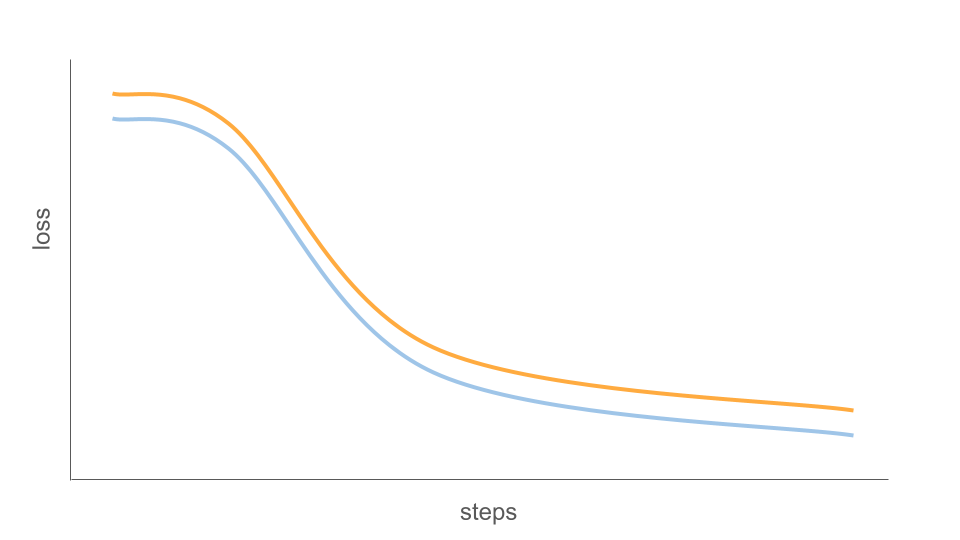

## Metrics to Monitor ##
Effective monitoring involves tracking quantitative metrics, and evaluating qualitative metrics. Available metrics are:
1. Training loss
2. Validation loss
3. Learning rate progression
4. Gradient norms

## The Path to Convergence ##
As training progresses, the loss curve should gradually stabilize. The key indicator of healthy training is a small gap between training and validation loss, suggesting the model is learning generalizable patterns rather than memorizing specific examples. The absolute loss values will vary depending on the task and datset

## Monitoring Training Progress ##
The graph above shows a typical training progression. We notice how training and validation loss decrease sharply at first, then gradually level off. This pattern indicates the model is learning effectively while maintaining generalization ability.

## Warning Signs to Watch For ##
Several patterns in the loss curves can indicate potential issues. Below we illustrate common warning signs and solutions that we can consider:
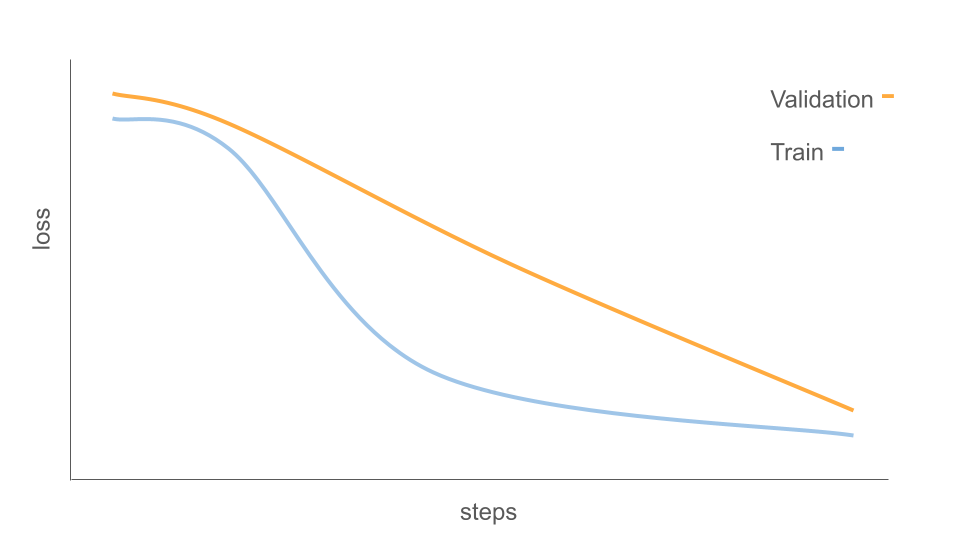
If the validation loss decreases at a significantly slower rate than training loss, the model is likely overfitting to the training data. Conider:
- Reducing the training steps
- Simplifying the training pipeline / Reconfigure the parameters
- Increasing the dataset size
- Validating dataset quality and diversity
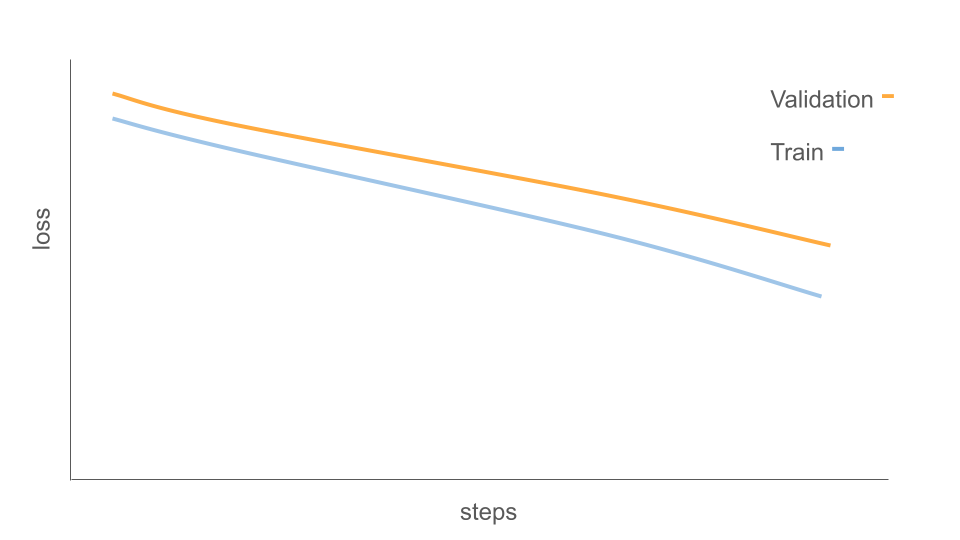
If the loss doesn't show significant improvement, the model might be:
- Learning too slowly (try increasing the learning rate)
- Struggling with the task (check data quality and task complexity)
- Hitting architecture limitations (consider a different model)
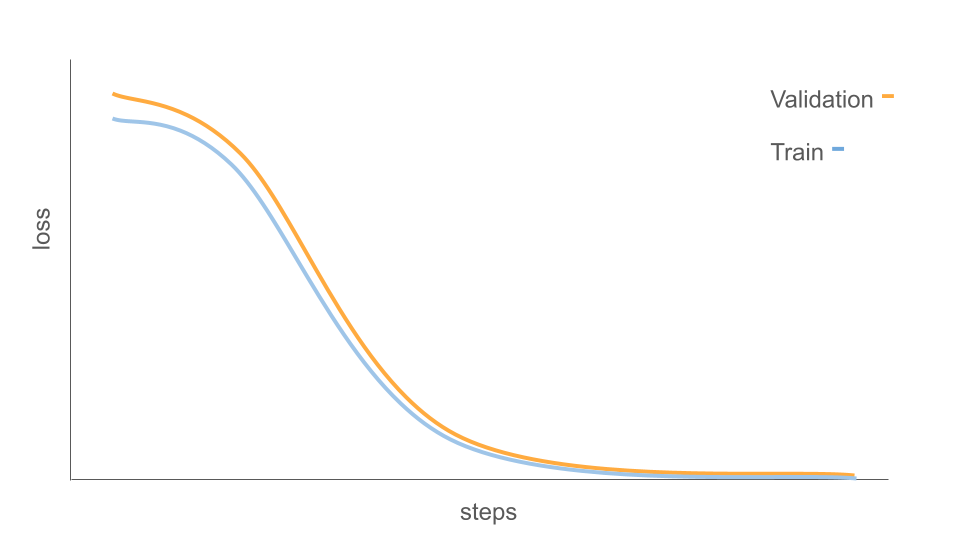
On the other side, extremely low loss values could suggest memorization rather than training. This is particularly concerning if:
- The model performs poorly on new, similar examples
- The outputs lack diversity
- The responses are too similar to training examples

Obs. and recommendation: Monitor both the loss values and the model’s actual outputs during training. Sometimes the loss can look good while the model develops unwanted behaviors. Regular qualitative evaluation of the model’s responses helps catch issues that metrics alone might miss.

We should note that the interpretation of the loss values we outline here is aimed on the most common case, and in fact, loss values can behave on various ways depending on the model, the dataset, the training parameters, etc.

## Evaluation after SFT ##

After completing SFT, consider these follow-up actions:
1. Evaluate the model thoroughly on held-out test data
2. Validate template adherence across various inputs
3. Test domain-specific knowledge retention
4. Monitor real-world performance metrics

To note: Document your training process, including:
- Dataset characteristics
- Training params.
- Performance metrics
- Known limitations

Exercise: Fine-Tuning SmolLM2 with SFTTrainer
Take a dataset from the Hugging Face hub and finetune a model on it.

Difficulty Levels

🐢 Use the `HuggingFaceTB/smoltalk` dataset

🐕 Try out the `bigcode/the-stack-smol` dataset and finetune a code generation model on a specific subset `data/python`.

🦁 Select a dataset that relates to a real world use case your interested in

In [ ]:
......